# Perturbed Reference Recovery Demo

### 数据读入

In [38]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]
REPO_ROOT = next((path for path in candidates if (path / "metasort").exists() and (path / "data").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the MetaSort repository root or notebooks directory.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metasort import MetaSortConfig, MetaSortSolver

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Repo root: {REPO_ROOT}")

Repo root: /home/yunhao/WeightOptimizationDebug/metasort_jk


In [39]:
DATA_ROOT = REPO_ROOT / "data" / "Blood"
n_mixtures = 100
cumulative_windows = [20, 40, 60, 80, 100]

# The perturbation is multiplicative and column-sum preserving.
perturb_sigma = 0.05
perturb_seed = 123
lambda_ref = 0.6
RECOMPUTE = True

cfg = MetaSortConfig(
    lambda_hessian=1.0,
    lambda_avg_gradient=1.0,
    lambda_residual=1.5,
    lambda_gene_importance=0.0,
    lambda3=0.01,
    lambda4=0.001,
    convergence_tol=0.005,
    cv_repeats=20,
    print_info=False,
)
solver = MetaSortSolver(cfg)

In [40]:
def make_perturbed_reference(true_reference: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    true_reference = np.asarray(true_reference, dtype=float)
    perturbed = true_reference * rng.lognormal(mean=0.0, sigma=sigma, size=true_reference.shape)
    perturbed = np.clip(perturbed, 0.0, None)

    # Keep each cell-type profile on the same total-expression scale as the true reference.
    true_col_sums = np.clip(true_reference.sum(axis=0, keepdims=True), 1e-12, None)
    perturbed_col_sums = np.clip(perturbed.sum(axis=0, keepdims=True), 1e-12, None)
    return perturbed * (true_col_sums / perturbed_col_sums)


def recover_reference_profiles(reference_prior: np.ndarray, bulk: np.ndarray, proportions: np.ndarray, lambda_ref: float) -> np.ndarray:
    reference_prior = np.asarray(reference_prior, dtype=float)
    bulk = np.asarray(bulk, dtype=float)
    proportions = np.asarray(proportions, dtype=float)
    denom = float(lambda_ref + np.sum(proportions ** 2))
    pred_bulk = reference_prior @ proportions
    residual = bulk - pred_bulk
    recovered = reference_prior + (residual[:, None] * proportions[None, :]) / max(denom, 1e-12)
    return np.clip(recovered, 0.0, None)


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    corr = spearmanr(x, y).correlation
    if pd.isna(corr):
        return np.nan
    return float(corr)

In [41]:
true_signature_df = pd.read_csv(DATA_ROOT / "signature.txt", sep="\t", index_col=0)
bulk_df = pd.read_csv(DATA_ROOT / "bulk.txt", sep="\t", index_col=0)
ratio_df = pd.read_csv(DATA_ROOT / "bulkRatio.txt", sep="\t", index_col=0)

common_genes = true_signature_df.index.intersection(bulk_df.index)
true_signature_df = true_signature_df.loc[common_genes]
bulk_df = bulk_df.loc[common_genes]
cell_types = true_signature_df.columns.to_list()
mixture_names = list(ratio_df.columns[:n_mixtures])

true_reference = true_signature_df.to_numpy(dtype=float)
perturbed_reference = make_perturbed_reference(true_reference, sigma=perturb_sigma, seed=perturb_seed)

baseline_spearman = {
    cell_type: safe_spearman(true_reference[:, idx], perturbed_reference[:, idx])
    for idx, cell_type in enumerate(cell_types)
}
print(true_reference.shape, len(mixture_names))
pd.Series(baseline_spearman, name="PerturbedVsTrueSpearman").round(4)

(539, 6) 100


erythrocyte           0.9995
classical_monocyte    0.9992
neutrophil            0.9995
memory_B_cell         0.9994
plasma_cell           0.9995
platelet              0.9996
Name: PerturbedVsTrueSpearman, dtype: float64

In [42]:
def expression_matrix_to_long(matrix: np.ndarray, value_name: str) -> pd.DataFrame:
    return (
        pd.DataFrame(matrix, index=common_genes, columns=cell_types)
        .rename_axis("Gene")
        .reset_index()
        .melt(id_vars="Gene", var_name="CellType", value_name=value_name)
    )


true_reference_long = expression_matrix_to_long(true_reference, "TrueExpression")
perturbed_reference_long = expression_matrix_to_long(perturbed_reference, "PerturbedExpression")


def run_one_mixture(mixture_name: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    bulk = bulk_df[mixture_name].to_numpy(dtype=float)
    result = solver.solve(perturbed_reference, bulk, cell_types=cell_types)
    p_hat = np.asarray(result.proportions, dtype=float)
    recovered = recover_reference_profiles(perturbed_reference, bulk, p_hat, lambda_ref=lambda_ref)

    recovered_long = expression_matrix_to_long(recovered, "RecoveredExpression")
    profile_df = (
        recovered_long
        .merge(true_reference_long, on=["Gene", "CellType"], how="left")
        .merge(perturbed_reference_long, on=["Gene", "CellType"], how="left")
    )
    profile_df.insert(0, "Mixture", mixture_name)
    profile_df.insert(0, "Tissue", "Blood")
    profile_df = profile_df[[
        "Tissue",
        "Mixture",
        "Gene",
        "CellType",
        "TrueExpression",
        "PerturbedExpression",
        "RecoveredExpression",
    ]]

    celltype_rows = []
    for idx, cell_type in enumerate(cell_types):
        recovered_corr = safe_spearman(true_reference[:, idx], recovered[:, idx])
        perturbed_corr = baseline_spearman[cell_type]
        celltype_rows.append({
            "Tissue": "Blood",
            "Mixture": mixture_name,
            "CellType": cell_type,
            "PerturbedVsTrueSpearman": perturbed_corr,
            "RecoveredVsTrueSpearman": recovered_corr,
            "Pass_0_8": bool(recovered_corr >= 0.8),
        })

    detail_df = pd.DataFrame(celltype_rows)
    mixture_row = {
        "Tissue": "Blood",
        "Mixture": mixture_name,
        "MeanPerturbedSpearman": float(detail_df["PerturbedVsTrueSpearman"].mean()),
        "MeanRecoveredSpearman": float(detail_df["RecoveredVsTrueSpearman"].mean()),
        "MinRecoveredSpearman": float(detail_df["RecoveredVsTrueSpearman"].min()),
        "MeanPass_0_8": bool(float(detail_df["RecoveredVsTrueSpearman"].mean()) >= 0.8),
        "AllCellTypesPass_0_8": bool((detail_df["RecoveredVsTrueSpearman"] >= 0.8).all()),
        "MetaSortIterations": int(result.iterations),
        "MetaSortConverged": bool(result.converged),
    }
    for idx, cell_type in enumerate(cell_types):
        mixture_row[f"Proportion_{cell_type}"] = float(p_hat[idx])
    return detail_df, profile_df, mixture_row


### 表达谱恢复

In [43]:
detail_out = REPO_ROOT / "perturbed_reference_recovery_detail_blood_first100_lambda0p8.csv"
mixture_out = REPO_ROOT / "perturbed_reference_recovery_summary_blood_first100_lambda0p8.csv"
profile_out = REPO_ROOT / "perturbed_reference_recovery_profiles_blood_first100_lambda0p8.csv"

if detail_out.exists() and mixture_out.exists() and profile_out.exists() and not RECOMPUTE:
    detail_df = pd.read_csv(detail_out)
    mixture_df = pd.read_csv(mixture_out)
    recovered_profile_df = pd.read_csv(profile_out)
else:
    detail_frames = []
    profile_frames = []
    mixture_rows = []
    for mixture_name in mixture_names:
        detail_piece, profile_piece, mixture_row = run_one_mixture(mixture_name)
        detail_frames.append(detail_piece)
        profile_frames.append(profile_piece)
        mixture_rows.append(mixture_row)

    detail_df = pd.concat(detail_frames, ignore_index=True)
    recovered_profile_df = pd.concat(profile_frames, ignore_index=True)
    mixture_df = pd.DataFrame(mixture_rows)
    detail_df.to_csv(detail_out, index=False)
    recovered_profile_df.to_csv(profile_out, index=False)
    mixture_df.to_csv(mixture_out, index=False)

mixture_df.head()

,Tissue,Mixture,MeanPerturbedSpearman,MeanRecoveredSpearman,MinRecoveredSpearman,MeanPass_0_8,AllCellTypesPass_0_8,MetaSortIterations,MetaSortConverged,Proportion_erythrocyte,Proportion_classical_monocyte,Proportion_neutrophil,Proportion_memory_B_cell,Proportion_plasma_cell,Proportion_platelet
0,Blood,Mixture1,0.999442,0.916552,0.642936,True,False,17,True,0.270883,0.555255,0.007847,0.024158,0.138692,0.003166
1,Blood,Mixture2,0.999442,0.953232,0.779516,True,False,27,True,0.000000,0.238707,0.589374,0.066760,0.028017,0.077142
2,Blood,Mixture3,0.999442,0.903367,0.661694,True,False,30,True,0.349468,0.074027,0.459237,0.017535,0.046032,0.053702
3,Blood,Mixture4,0.999442,0.910372,0.697458,True,False,18,True,0.332072,0.238316,0.357643,0.013327,0.057983,0.000659
4,Blood,Mixture5,0.999442,0.931990,0.734387,True,False,15,True,0.269243,0.413747,0.161606,0.089854,0.040741,0.024809


In [44]:
plot_df = mixture_df.copy()
plot_df["MixtureIndex"] = plot_df["Mixture"].str.extract(r"(\d+)").astype(int)
plot_df = plot_df.sort_values("MixtureIndex")

summary_by_window = pd.DataFrame([
    {
        "MixtureRange": f"1-{n}",
        "N": int((plot_df["MixtureIndex"] <= n).sum()),
        "MeanOfMeanRecoveredSpearman": float(plot_df.loc[plot_df["MixtureIndex"] <= n, "MeanRecoveredSpearman"].mean()),
        "MedianOfMeanRecoveredSpearman": float(plot_df.loc[plot_df["MixtureIndex"] <= n, "MeanRecoveredSpearman"].median()),
        "MeanPassRate_Ge0_8": float(plot_df.loc[plot_df["MixtureIndex"] <= n, "MeanPass_0_8"].mean()),
        "MinRecoveredSpearman": float(plot_df.loc[plot_df["MixtureIndex"] <= n, "MinRecoveredSpearman"].min()),
    }
    for n in cumulative_windows
])
summary_by_window.round(4)

,MixtureRange,N,MeanOfMeanRecoveredSpearman,MedianOfMeanRecoveredSpearman,MeanPassRate_Ge0_8,MinRecoveredSpearman
0,1-20,20,0.9212,0.9174,1.0,0.5914
1,1-40,40,0.9236,0.9198,1.0,0.5914
2,1-60,60,0.9249,0.9227,1.0,0.5914
3,1-80,80,0.9243,0.9221,1.0,0.5914
4,1-100,100,0.9241,0.9213,1.0,0.5914


### 绘图展示斯皮尔曼系数

/tmp/ipykernel_1008242/3662114588.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="lower right")


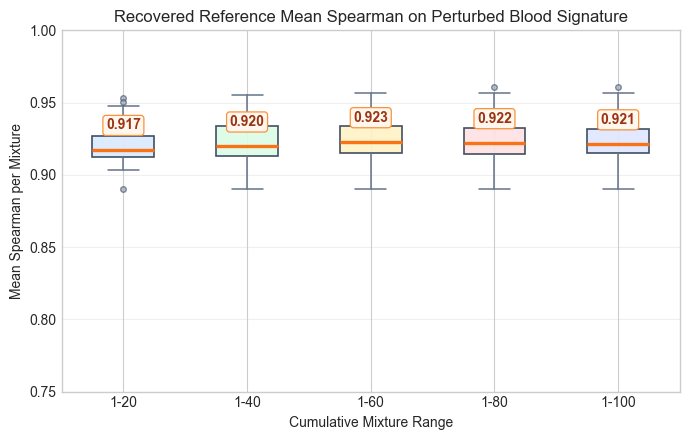

In [45]:
groups = [plot_df.loc[plot_df["MixtureIndex"] <= n, "MeanRecoveredSpearman"].to_numpy() for n in cumulative_windows]
labels = [f"1-{n}" for n in cumulative_windows]
median_values = [float(np.median(values)) for values in groups]

fig, ax = plt.subplots(figsize=(7, 4.5))
box = ax.boxplot(
    groups,
    tick_labels=labels,
    patch_artist=True,
    medianprops={"color": "#f97316", "linewidth": 2.4},
    boxprops={"linewidth": 1.2, "color": "#334155"},
    whiskerprops={"linewidth": 1.1, "color": "#64748b"},
    capprops={"linewidth": 1.1, "color": "#64748b"},
    flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "#94a3b8", "markeredgecolor": "#475569", "alpha": 0.65},
)

box_colors = ["#dbeafe", "#dcfce7", "#fef3c7", "#fee2e2", "#e0e7ff"]
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.92)

for x, median_value in enumerate(median_values, start=1):
    ax.text(
        x,
        median_value + 0.012,
        f"{median_value:.3f}",
        ha="center",
        va="bottom",
        color="#9a3412",
        fontsize=10,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.22", "facecolor": "#fff7ed", "edgecolor": "#fb923c", "linewidth": 0.9},
    )

# ax.axhline(0.8, color="red", linestyle="--", linewidth=1.5, label="0.8 threshold")
ax.set_title("Recovered Reference Mean Spearman on Perturbed Blood Signature")
ax.set_xlabel("Cumulative Mixture Range")
ax.set_ylabel("Mean Spearman per Mixture")
ax.set_ylim(0.75, 1.0)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()